In [1]:
# Import the required libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import missingno as msno
import warnings
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
from sklearn.feature_selection import RFE
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
%matplotlib inline
warnings.filterwarnings('ignore')
sns.set_theme(style="whitegrid")

### Load the Dataset

In [2]:
filename = "/home/shanujya/BITS_MSC/DPP/Fifa21_rating_predictor/fifa21 datatset.csv"
df = pd.read_csv(filename)

In [3]:
# preview the data
df.head()

,ID,Name,LongName,photoUrl,playerUrl,Nationality,Age,↓OVA,POT,Club,...,A/W,D/W,IR,PAC,SHO,PAS,DRI,DEF,PHY,Hits
0,158023,L. Messi,Lionel Messi,https://cdn.sofifa.com/players/158/023/21_60.png,http://sofifa.com/player/158023/lionel-messi/2...,Argentina,33,93,93,\n\n\n\nFC Barcelona,...,Medium,Low,5 ★,85,92,91,95,38,65,771
1,20801,Cristiano Ronaldo,C. Ronaldo dos Santos Aveiro,https://cdn.sofifa.com/players/020/801/21_60.png,http://sofifa.com/player/20801/c-ronaldo-dos-s...,Portugal,35,92,92,\n\n\n\nJuventus,...,High,Low,5 ★,89,93,81,89,35,77,562
2,200389,J. Oblak,Jan Oblak,https://cdn.sofifa.com/players/200/389/21_60.png,http://sofifa.com/player/200389/jan-oblak/210006/,Slovenia,27,91,93,\n\n\n\nAtlético Madrid,...,Medium,Medium,3 ★,87,92,78,90,52,90,150
3,192985,K. De Bruyne,Kevin De Bruyne,https://cdn.sofifa.com/players/192/985/21_60.png,http://sofifa.com/player/192985/kevin-de-bruyn...,Belgium,29,91,91,\n\n\n\nManchester City,...,High,High,4 ★,76,86,93,88,64,78,207
4,190871,Neymar Jr,Neymar da Silva Santos Jr.,https://cdn.sofifa.com/players/190/871/21_60.png,http://sofifa.com/player/190871/neymar-da-silv...,Brazil,28,91,91,\n\n\n\nParis Saint-Germain,...,High,Medium,5 ★,91,85,86,94,36,59,595


In [4]:
# Dimension of the dataset
df.shape

(18979, 77)

In [5]:
pd.set_option('display.max_columns', None) #To be able to browse through all 77 columns.

df.head()

,ID,Name,LongName,photoUrl,playerUrl,Nationality,Age,↓OVA,POT,Club,Contract,Positions,Height,Weight,Preferred Foot,BOV,Best Position,Joined,Loan Date End,Value,Wage,Release Clause,Attacking,Crossing,Finishing,Heading Accuracy,Short Passing,Volleys,Skill,Dribbling,Curve,FK Accuracy,Long Passing,Ball Control,Movement,Acceleration,Sprint Speed,Agility,Reactions,Balance,Power,Shot Power,Jumping,Stamina,Strength,Long Shots,Mentality,Aggression,Interceptions,Positioning,Vision,Penalties,Composure,Defending,Marking,Standing Tackle,Sliding Tackle,Goalkeeping,GK Diving,GK Handling,GK Kicking,GK Positioning,GK Reflexes,Total Stats,Base Stats,W/F,SM,A/W,D/W,IR,PAC,SHO,PAS,DRI,DEF,PHY,Hits
0,158023,L. Messi,Lionel Messi,https://cdn.sofifa.com/players/158/023/21_60.png,http://sofifa.com/player/158023/lionel-messi/2...,Argentina,33,93,93,\n\n\n\nFC Barcelona,2004 ~ 2021,"RW, ST, CF",170cm,72kg,Left,93,RW,"Jul 1, 2004",NaN,€103.5M,€560K,€138.4M,429,85,95,70,91,88,470,96,93,94,91,96,451,91,80,91,94,95,389,86,68,72,69,94,347,44,40,93,95,75,96,91,32,35,24,54,6,11,15,14,8,2231,466,4 ★,4★,Medium,Low,5 ★,85,92,91,95,38,65,771
1,20801,Cristiano Ronaldo,C. Ronaldo dos Santos Aveiro,https://cdn.sofifa.com/players/020/801/21_60.png,http://sofifa.com/player/20801/c-ronaldo-dos-s...,Portugal,35,92,92,\n\n\n\nJuventus,2018 ~ 2022,"ST, LW",187cm,83kg,Right,92,ST,"Jul 10, 2018",NaN,€63M,€220K,€75.9M,437,84,95,90,82,86,414,88,81,76,77,92,431,87,91,87,95,71,444,94,95,84,78,93,353,63,29,95,82,84,95,84,28,32,24,58,7,11,15,14,11,2221,464,4 ★,5★,High,Low,5 ★,89,93,81,89,35,77,562
2,200389,J. Oblak,Jan Oblak,https://cdn.sofifa.com/players/200/389/21_60.png,http://sofifa.com/player/200389/jan-oblak/210006/,Slovenia,27,91,93,\n\n\n\nAtlético Madrid,2014 ~ 2023,GK,188cm,87kg,Right,91,GK,"Jul 16, 2014",NaN,€120M,€125K,€159.4M,95,13,11,15,43,13,109,12,13,14,40,30,307,43,60,67,88,49,268,59,78,41,78,12,140,34,19,11,65,11,68,57,27,12,18,437,87,92,78,90,90,1413,489,3 ★,1★,Medium,Medium,3 ★,87,92,78,90,52,90,150
3,192985,K. De Bruyne,Kevin De Bruyne,https://cdn.sofifa.com/players/192/985/21_60.png,http://sofifa.com/player/192985/kevin-de-bruyn...,Belgium,29,91,91,\n\n\n\nManchester City,2015 ~ 2023,"CAM, CM",181cm,70kg,Right,91,CAM,"Aug 30, 2015",NaN,€129M,€370K,€161M,407,94,82,55,94,82,441,88,85,83,93,92,398,77,76,78,91,76,408,91,63,89,74,91,408,76,66,88,94,84,91,186,68,65,53,56,15,13,5,10,13,2304,485,5 ★,4★,High,High,4 ★,76,86,93,88,64,78,207
4,190871,Neymar Jr,Neymar da Silva Santos Jr.,https://cdn.sofifa.com/players/190/871/21_60.png,http://sofifa.com/player/190871/neymar-da-silv...,Brazil,28,91,91,\n\n\n\nParis Saint-Germain,2017 ~ 2022,"LW, CAM",175cm,68kg,Right,91,LW,"Aug 3, 2017",NaN,€132M,€270K,€166.5M,408,85,87,62,87,87,448,95,88,89,81,95,453,94,89,96,91,83,357,80,62,81,50,84,356,51,36,87,90,92,93,94,35,30,29,59,9,9,15,15,11,2175,451,5 ★,5★,High,Medium,5 ★,91,85,86,94,36,59,595


In [6]:
# Summary of the data
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 18979 entries, 0 to 18978
Data columns (total 77 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   ID                18979 non-null  int64 
 1   Name              18979 non-null  str   
 2   LongName          18979 non-null  str   
 3   photoUrl          18979 non-null  str   
 4   playerUrl         18979 non-null  str   
 5   Nationality       18979 non-null  str   
 6   Age               18979 non-null  int64 
 7   ↓OVA              18979 non-null  int64 
 8   POT               18979 non-null  int64 
 9   Club              18979 non-null  str   
 10  Contract          18979 non-null  str   
 11  Positions         18979 non-null  str   
 12  Height            18979 non-null  str   
 13  Weight            18979 non-null  str   
 14  Preferred Foot    18979 non-null  str   
 15  BOV               18979 non-null  int64 
 16  Best Position     18979 non-null  str   
 17  Joined            18979

In [7]:
# View descriptive statistics of the data
df.describe()

,ID,Age,↓OVA,POT,BOV,Attacking,Crossing,Finishing,Heading Accuracy,Short Passing,Volleys,Skill,Dribbling,Curve,FK Accuracy,Long Passing,Ball Control,Movement,Acceleration,Sprint Speed,Agility,Reactions,Balance,Power,Shot Power,Jumping,Stamina,Strength,Long Shots,Mentality,Aggression,Interceptions,Positioning,Vision,Penalties,Composure,Defending,Marking,Standing Tackle,Sliding Tackle,Goalkeeping,GK Diving,GK Handling,GK Kicking,GK Positioning,GK Reflexes,Total Stats,Base Stats,PAC,SHO,PAS,DRI,DEF,PHY
count,18979.000000,18979.000000,18979.000000,18979.000000,18979.000000,18979.000000,18979.000000,18979.000000,18979.000000,18979.000000,18979.000000,18979.000000,18979.000000,18979.000000,18979.000000,18979.000000,18979.000000,18979.000000,18979.000000,18979.000000,18979.000000,18979.000000,18979.000000,18979.000000,18979.000000,18979.000000,18979.000000,18979.000000,18979.000000,18979.000000,18979.000000,18979.000000,18979.000000,18979.000000,18979.000000,18979.00000,18979.000000,18979.000000,18979.000000,18979.000000,18979.000000,18979.000000,18979.000000,18979.000000,18979.000000,18979.000000,18979.000000,18979.000000,18979.000000,18979.000000,18979.000000,18979.000000,18979.000000,18979.000000
mean,226403.384794,25.194109,65.718636,71.136414,66.751726,248.938142,49.688392,45.842405,51.942726,58.768112,42.696507,256.479214,55.587491,47.246957,42.391011,52.725381,58.528373,317.718689,64.357553,64.412930,63.366721,61.655619,63.925865,296.605195,57.801676,64.577375,62.653986,64.786922,46.785236,254.199747,55.591285,46.394489,50.298962,53.857105,48.057906,58.07366,139.909268,46.559197,47.705622,45.644449,81.436693,16.416302,16.207124,16.076453,16.217187,16.519627,1595.286949,355.702197,67.453975,53.457031,57.681016,62.875020,49.866221,64.368934
std,27141.054157,4.710520,6.968999,6.114635,6.747193,74.299428,18.131153,19.567081,17.294409,14.519106,17.646937,78.650601,18.761314,18.207790,17.227947,15.178151,16.565892,55.879046,14.889981,14.638743,14.596277,9.072114,14.062285,50.732390,13.308747,11.844870,15.804223,12.488672,19.300534,64.595613,17.140414,20.698078,19.428701,13.708574,15.655999,12.07911,61.219472,20.139324,21.367690,20.922087,84.665579,17.554194,16.816305,16.491103,17.002239,17.854079,269.874789,40.761117,10.677859,13.827425,10.081857,9.927415,16.443213,9.601883
min,41.000000,16.000000,47.000000,47.000000,48.000000,42.000000,6.000000,3.000000,5.000000,7.000000,3.000000,40.000000,5.000000,4.000000,5.000000,5.000000,5.000000,122.000000,13.000000,12.000000,14.000000,24.000000,12.000000,122.000000,18.000000,15.000000,12.000000,16.000000,4.000000,50.000000,9.000000,3.000000,2.000000,9.000000,6.000000,12.00000,20.000000,3.000000,5.000000,4.000000,10.000000,2.000000,2.000000,2.000000,2.000000,2.000000,747.000000,232.000000,25.000000,16.000000,25.000000,25.000000,12.000000,28.000000
25%,210135.000000,21.000000,61.000000,67.000000,62.000000,222.000000,38.000000,30.000000,44.000000,54.000000,30.000000,222.000000,49.000000,35.000000,31.000000,43.000000,54.000000,289.000000,57.000000,57.000000,55.000000,56.000000,56.000000,264.000000,48.000000,58.000000,55.000000,57.000000,32.000000,227.500000,44.000000,25.000000,40.000000,45.000000,39.000000,50.00000,83.000000,29.000000,27.000000,25.000000,48.000000,8.000000,8.000000,8.000000,8.000000,8.000000,1452.000000,327.000000,61.000000,44.000000,51.000000,57.000000,35.000000,58.000000
50%,232418.000000,25.000000,66.000000,71.000000,67.000000,263.000000,54.000000,49.000000,55.000000,62.000000,44.000000,269.000000,61.000000,49.000000,41.000000,56.000000,63.000000,327.000000,67.000000,67.000000,66.000000,62.000000,66.000000,302.000000,59.000000,65.000000,66.000000,66.000000,51.000000,263.000000,58.000000,53.000000,55.000000,55.000000,49.000000,59.00000,159.000000,52.000000,55.000000,52.000000,53.000000,11.000000,11.000000,11.000000,11.000000,11.000000,1627.000000,356.000000,68.000000,56.000000,58.000000,64.000000,53.000000,65.000000
75%,246922.500000,29.000000,70.000000,75.000000,71.000000,297.



## Task A: Dataset Understanding

**1.Dataset Description:**
* Number of Records(Rows):18979
* Number of Features(Columns):77
* Target Variable: ↓OVA

**2.Attribute Types Identification:**
* **Nominal Attributes(Categorical,No order):** Name, Nationality, Club, Preferred Foot, Best Position.
* **Ordianl Attributes(Categorical with logical order):** W/F (Weak Foot rating), SM (Skill Moves rating), IR (International Reputation) – these are given in stars (★) and some of them have given high,low and medium ratings like A/W (Attacking Work Rate),D/W (Defensive Work Rate).
* **Numeric-Discrete:** Age, Attacking, Crossing, Finishing, Total Stats (countable whole numbers).
* **Numeric-Continuous:** Value, Wage, Height, Weight (These are currently stored as strings/objects due to symbols like '€', 'M', 'cm', 'kg', but logically they represent continuous measurements).

**3.Data Dictionary Table:**
| Feature | Type | Description |
| :--- | :--- | :--- |
| ↓OVA | Numeric (Discrete) | The player's overall rating (Target Variable) |
| Age | Numeric (Discrete) | The player's age in years |
| Club | Nominal | The football club the player is currently signed to |
| Value | Numeric (Continuous) | Player's market value in Euros (€) |
| W/F | Ordinal | Weak foot rating out of 5 stars |

In [8]:
# Rename the target variable column for easier access
df.rename(columns={'↓OVA': 'OVA'}, inplace=True)

## Task B: Data Quality Analysis

In [9]:
# Check missing values in the dataset
df.isnull().sum()

ID              0
Name            0
LongName        0
photoUrl        0
playerUrl       0
             ... 
PAS             0
DRI             0
DEF             0
PHY             0
Hits         2595
Length: 77, dtype: int64

In [10]:
# Missing values
missing_values = df.isnull().sum()
missing_values = missing_values[missing_values>0].sort_values(ascending=False)
print(missing_values)

Loan Date End    17966
Hits              2595
dtype: int64


Only Two columns have missing values but they are significant:
* **Loan Date End:** 17966 missing values,as most players are not on loan
* **Hits:** 2595 missing values.

### Visualize the missing values

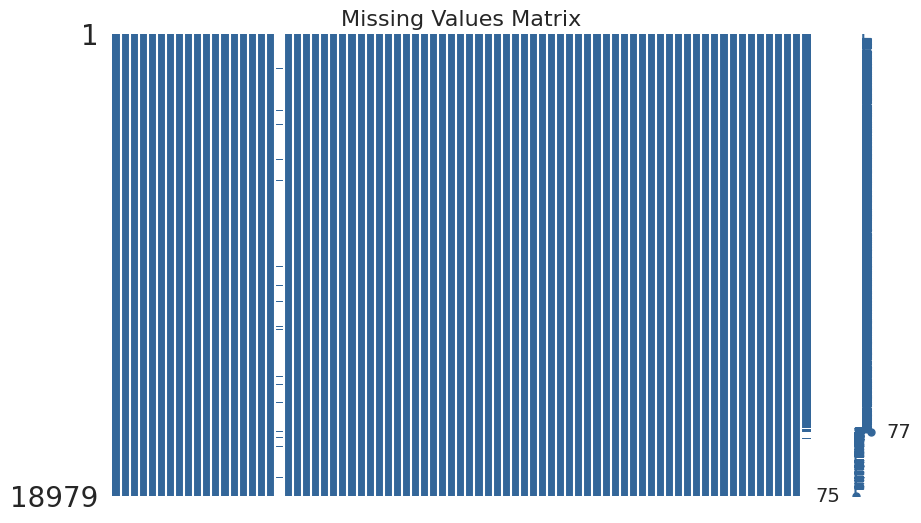

In [11]:
# MSNO matric plot
msno.matrix(df,figsize=(10,6),color=(0.2, 0.4, 0.6))
plt.title("Missing Values Matrix", fontsize=16)
plt.show()

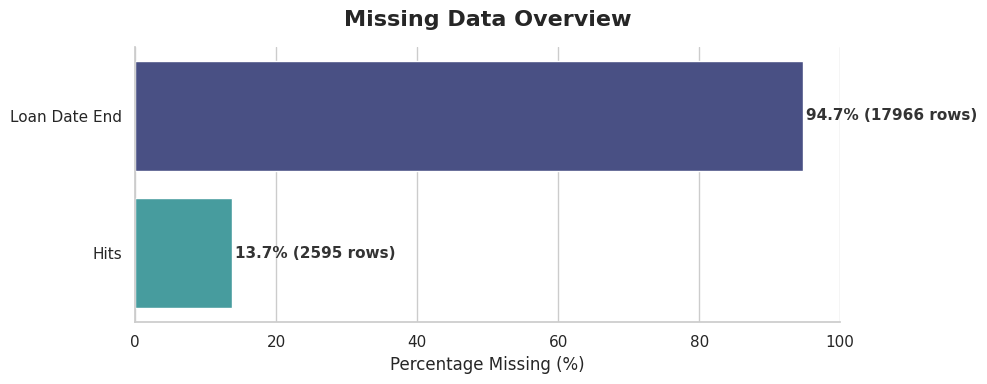

In [12]:
missing_percentages = (missing_values / len(df)) * 100

missing_data = pd.DataFrame({
    'Count': missing_values, 
    'Percentage': missing_percentages
})

plt.figure(figsize=(10, 4)) 
sns.set_theme(style="whitegrid")

# Create a horizontal bar chart
ax = sns.barplot(
    x=missing_data['Percentage'], 
    y=missing_data.index, 
    palette='mako' 
)

# Add data labels (Percentage and Count) directly onto the bars
for p in ax.patches:
    width = p.get_width()
    # Calculate the original count to display alongside the percentage
    count = int(round(width * len(df) / 100))
    plt.text(
        width + 0.5, # Push the text slightly to the right of the bar
        p.get_y() + p.get_height() / 2, # Center it vertically
        f'{width:.1f}% ({count} rows)', 
        ha="left", 
        va="center", 
        fontsize=11,
        fontweight='bold',
        color='#333333'
    )

plt.title('Missing Data Overview', fontsize=16, fontweight='bold', pad=15)
plt.xlabel('Percentage Missing (%)', fontsize=12)
plt.ylabel('') # Remove the y-axis label since the feature names are self-explanatory
plt.xlim(0, 100) # Lock the x-axis from 0 to 100%

# Remove the top and right borders for a cleaner, modern look
sns.despine(right=True, top=True)

plt.tight_layout()
plt.show()

In [13]:
# Check Duplicate values
duplicate_val = df.duplicated().sum()
print(f"\nNumber of Duplicate Values detected:{duplicate_val}")


Number of Duplicate Values detected:0


There are 0 perfectly duplicate rows in this dataset.

In [14]:
# Spotting Noisy data
# Noisy column that needs string manipulation
noisy_cols = ['Club', 'Height', 'Weight', 'Value', 'Wage', 'Release Clause', 'W/F', 'SM', 'IR', 'Hits', 'Contract','Joined','Loan Date End','Positions','photoUrl','playerUrl','LongName']
print("\nNoisy Data Sample:")
df[noisy_cols].head()


Noisy Data Sample:


,Club,Height,Weight,Value,Wage,Release Clause,W/F,SM,IR,Hits,Contract,Joined,Loan Date End,Positions,photoUrl,playerUrl,LongName
0,\n\n\n\nFC Barcelona,170cm,72kg,€103.5M,€560K,€138.4M,4 ★,4★,5 ★,771,2004 ~ 2021,"Jul 1, 2004",NaN,"RW, ST, CF",https://cdn.sofifa.com/players/158/023/21_60.png,http://sofifa.com/player/158023/lionel-messi/2...,Lionel Messi
1,\n\n\n\nJuventus,187cm,83kg,€63M,€220K,€75.9M,4 ★,5★,5 ★,562,2018 ~ 2022,"Jul 10, 2018",NaN,"ST, LW",https://cdn.sofifa.com/players/020/801/21_60.png,http://sofifa.com/player/20801/c-ronaldo-dos-s...,C. Ronaldo dos Santos Aveiro
2,\n\n\n\nAtlético Madrid,188cm,87kg,€120M,€125K,€159.4M,3 ★,1★,3 ★,150,2014 ~ 2023,"Jul 16, 2014",NaN,GK,https://cdn.sofifa.com/players/200/389/21_60.png,http://sofifa.com/player/200389/jan-oblak/210006/,Jan Oblak
3,\n\n\n\nManchester City,181cm,70kg,€129M,€370K,€161M,5 ★,4★,4 ★,207,2015 ~ 2023,"Aug 30, 2015",NaN,"CAM, CM",https://cdn.sofifa.com/players/192/985/21_60.png,http://sofifa.com/player/192985/kevin-de-bruyn...,Kevin De Bruyne
4,\n\n\n\nParis Saint-Germain,175cm,68kg,€132M,€270K,€166.5M,5 ★,5★,5 ★,595,2017 ~ 2022,"Aug 3, 2017",NaN,"LW, CAM",https://cdn.sofifa.com/players/190/871/21_60.png,http://sofifa.com/player/190871/neymar-da-silv...,Neymar da Silva Santos Jr.


As we can see there are lot of noisy data in this dataset:
* **Club Name:** Newline string character attached to them(e.g. \n\n\n\nFC Barcelona)
* **Measurment:** 'kg' and 'cm' attached with numeric value that is why pandas treated them as string.Some players have their height listed in feet and inches (e.g., 6'2") and Some players are listed in pounds (e.g., 183lbs).
* **Currency Strings:** Value, Wage, and Release Clause have '€' symbols and 'M' (Millions) or 'K' (Thousands) suffixes (e.g., €103.5M, €560K). These must be converted to raw numbers.
* **Star Rating:** W/F, SM, and IR contain the star symbol ★ which forces pandas to treat them as text instead of numbers.
* **Contract and Joined:** Contract column contain range strings like "2004 ~ 2021" this. ML models cannot read this mathematically.it is also contain tricky string entries like "On Loan" or "Free".Subsequently with Joined column,it has entries like "Jul 1, 2004".ML models does not understand 'Jul'.So these are noisy data which needs to be processed.
* **Hits:** in df.info(),this column registered as an Object,rather than number.because some value abbreviated as '1.5K' so we have to handle these abbreviation.
* **Positions:** This column contains multiple positions separated by commas (e.g., "RW, ST, CF").
* **photoUrl and playerUrl:** These are pure noise. Web links have zero predictive power for a machine learning model trying to guess a player's stats or value.

#### Outlier Detection Note:

While the assignment structure lists outlier detection in Task B and Data cleaning in Task C,It is mathematically impossible to calculate Z-Scores or Interquartile Range on string-based currency and unit-mixed measurment.Therefore, I will perform an initial data cleaning to convert these features into pure numeric types before executing the outlier detection.

## Task C: Data Cleaning

In [15]:
# First i will delete useless metadata and highle missing column
cols_to_drop = ['LongName', 'photoUrl', 'playerUrl', 'Loan Date End']
df = df.drop(columns=cols_to_drop)

**1.Dropping Irrelevent and Highly Sparse Features:** Dropped photoUrl, playerUrl, LongName, and Loan Date End.


**Justification:** photoUrl and playerUrl are web metadata with zero predictive power for a machine learning model. LongName is redundant since the Name column already serves as a unique identifier.he Loan Date End column was dropped because it contained over 94% missing values (17,966 NaNs); imputing this volume of missing data would introduce severe bias into the dataset.

In [16]:
# Clean Currency (Value,Wage,Release Clause)
def clean_currency(X):
    if pd.isna(X): return np.nan
    X = str(X).replace('€', '')
    if 'M' in X: return float(X.replace('M',''))* 1000000
    elif 'K' in X: return float(X.replace('K',''))* 1000
    return float(X);

for col in ['Value','Wage','Release Clause']:
    df[col] = df[col].apply(clean_currency)

**2.Standardizing Currency Features:** Value, Wage, and Release Clause by removing '€' symbols and mathematically converting 'M' (Millions) and 'K' (Thousands) abbreviations.

**Justification:** ML algorithms requires continuous numerical inputs for regression or distance calculations.Leaving them as string object cause model to fail.By writing custom mapping function,these features were successfully converted from messy strings into usable continuous float variables.

In [17]:
# Handle the Height and Weight measurments of the player

# vectorized weight conversion
# Extract the raw numbers from the string
weight_num = df['Weight'].str.extract(r'(\d+)')[0].astype(float)

# Use boolean masking to identify which row contains 'lbs'
is_lbs = df['Weight'].str.contains('lbs',na=False)

# Use np.where to apply the conversion ONLY to the 'lbs' rows, otherwise keep the raw kg number
df['Weight'] = np.where(is_lbs,weight_num*0.453592,weight_num).round(2)

In [18]:
# vecotrized height conversion
# extract the raw numbers from the string which contains 'cm'
height_cm = df['Height'].str.extract(r'(\d+)cm')[0].astype(float)

# extract feet and inches for the rows, then calculate the total cm
feet_inches = df['Height'].str.extract(r'(\d+)\'\s*(\d+)"').astype(float)
height_convert = (feet_inches[0] * 30.48) + (feet_inches[1] * 2.54)

df['Height'] = height_cm.fillna(height_convert).round(2)

**3.Resolving Mixed-Unit Measurements:** Cleaned Height and Weight using vectorized Regular Expressions (Regex) and conditional masking.

**Justification:** These columns contained hidden unit-mixed strings (e.g., metric cm/kg mixed with imperial feet/lbs).If left unstandardized, a model would incorrectly equate 183 lbs with 183 kg. Conditional logic was applied to mathematically convert imperial measurements to metric before casting the entire column to a continuous numeric type.

In [19]:
# Clean star ratings
for col in ['W/F','SM','IR']:
    df[col] = df[col].str.replace('★','').str.strip().astype(int)

**4.Cleaning Ordinal Star Ratings:** Stripped the '★' symbol from W/F (Weak Foot), SM (Skill Moves), and IR (International Reputation) and converted them to integers.

**Justification:** These are ordinal categorical variables where the rank (1 to 5) has mathematical significance. Removing the text symbol and casting them as integers preserves this implicit hierarchy for the machine learning model.

In [20]:
# Clean Hits convert K to Thousands
def clean_hits(x):
    if pd.isna(x): return np.nan
    x = str(x)
    if 'K' in x: return float(x.replace('K', '')) * 1000
    return float(x)

df['Hits'] = df['Hits'].apply(clean_hits)

In [21]:
# Clean Club names
df['Club'] = df['Club'].str.strip()

# Keep the only one (Primary) position for the players instead of multiple ones
df['Positions'] = df['Positions'].str.split(',').str[0].str.strip()

**5.Standardizing Categorical Labels & Lists:** Stripped \n characters from Club, and extracted only the first listed string from the Positions column.

**Justifications:** The scraped dataset contained newline escape characters (\n\n\n\n) that created inconsistent categorical labels. Furthermore, Positions contained comma-separated lists (e.g., "RW, ST, CF"). Models require single, distinct categorical values to create proper feature splits, so only the primary position was retained.

In [22]:
# Extract the joined year
df['Joined_Year'] = pd.to_datetime(df['Joined'],errors='coerce').dt.year
df = df.drop(columns=['Joined'])

In [23]:
# Handle the Contract Feature

# I will create the categorical feature from contract year for the status
df['Contract_status'] = np.where(df['Contract']=='Free','Free',
                                np.where(df['Contract']=='On Loan','On Loan','Active'))

# extract the start date from the Contract
df['Contract_Start'] = df['Contract'].str.extract(r'^(\d{4})\s*~')[0].astype('Int64')

# extract the end data from the contract
df['Contract_End'] = df['Contract'].str.extract(r'~\s*(\d{4})$')[0].astype('Int64')

# Drop the original messy column
df = df.drop(columns=['Contract'])

# Verify the changes
print(df[['Contract_status', 'Contract_Start', 'Contract_End']].head(10))

  Contract_status  Contract_Start  Contract_End
0          Active            2004          2021
1          Active            2018          2022
2          Active            2014          2023
3          Active            2015          2023
4          Active            2017          2022
5          Active            2014          2023
6          Active            2017          2023
7          Active            2018          2024
8          Active            2018          2022
9          Active            2014          2022


**6. Feature Engineering from Date and Text Strings:** Extracted Joined_Year from the Joined date. Engineered Contract_Start, Contract_End, and Contract_Status from the Contract column.

**Justification:** Raw date string (e.g., "Jul 1, 2004") and textual ranges (e.g., "2019 ~ 2024" or "On Loan") can not be parsed by standard algorithms.Extracting the specific numerical years converts them into usable discrete features.Furthermore, using Pandas' **Nullable Integer (Int64)** type instead of float type for the Contract years allowed us to maintain integer logic while safely accommodating the NaN values inherently generated by "Free" agents and "On Loan" players.

In [24]:
df[['Club', 'Height', 'Weight', 'Value', 'Wage', 'Release Clause', 'W/F', 'SM', 'IR', 'Hits', 'Joined_Year','Positions','Contract_status', 'Contract_Start', 'Contract_End']].head()

,Club,Height,Weight,Value,Wage,Release Clause,W/F,SM,IR,Hits,Joined_Year,Positions,Contract_status,Contract_Start,Contract_End
0,FC Barcelona,170.0,72.0,103500000.0,560000.0,138400000.0,4,4,5,771.0,2004,RW,Active,2004,2021
1,Juventus,187.0,83.0,63000000.0,220000.0,75900000.0,4,5,5,562.0,2018,ST,Active,2018,2022
2,Atlético Madrid,188.0,87.0,120000000.0,125000.0,159400000.0,3,1,3,150.0,2014,GK,Active,2014,2023
3,Manchester City,181.0,70.0,129000000.0,370000.0,161000000.0,5,4,4,207.0,2015,CAM,Active,2015,2023
4,Paris Saint-Germain,175.0,68.0,132000000.0,270000.0,166500000.0,5,5,5,595.0,2017,LW,Active,2017,2022


In [25]:
df.describe()

,ID,Age,OVA,POT,Height,Weight,BOV,Value,Wage,Release Clause,Attacking,Crossing,Finishing,Heading Accuracy,Short Passing,Volleys,Skill,Dribbling,Curve,FK Accuracy,Long Passing,Ball Control,Movement,Acceleration,Sprint Speed,Agility,Reactions,Balance,Power,Shot Power,Jumping,Stamina,Strength,Long Shots,Mentality,Aggression,Interceptions,Positioning,Vision,Penalties,Composure,Defending,Marking,Standing Tackle,Sliding Tackle,Goalkeeping,GK Diving,GK Handling,GK Kicking,GK Positioning,GK Reflexes,Total Stats,Base Stats,W/F,SM,IR,PAC,SHO,PAS,DRI,DEF,PHY,Hits,Joined_Year,Contract_Start,Contract_End
count,18979.000000,18979.000000,18979.000000,18979.000000,18979.000000,18979.000000,18979.000000,1.897900e+04,18979.000000,1.897900e+04,18979.000000,18979.000000,18979.000000,18979.000000,18979.000000,18979.000000,18979.000000,18979.000000,18979.000000,18979.000000,18979.000000,18979.000000,18979.000000,18979.000000,18979.000000,18979.000000,18979.000000,18979.000000,18979.000000,18979.000000,18979.000000,18979.000000,18979.000000,18979.000000,18979.000000,18979.000000,18979.000000,18979.000000,18979.000000,18979.000000,18979.00000,18979.000000,18979.000000,18979.000000,18979.000000,18979.000000,18979.000000,18979.000000,18979.000000,18979.000000,18979.000000,18979.000000,18979.000000,18979.000000,18979.000000,18979.000000,18979.000000,18979.000000,18979.000000,18979.000000,18979.000000,18979.000000,16384.000000,18979.000000,17729.0,17729.0
mean,226403.384794,25.194109,65.718636,71.136414,181.200409,75.019127,66.751726,2.865063e+06,9092.062279,3.962951e+06,248.938142,49.688392,45.842405,51.942726,58.768112,42.696507,256.479214,55.587491,47.246957,42.391011,52.725381,58.528373,317.718689,64.357553,64.412930,63.366721,61.655619,63.925865,296.605195,57.801676,64.577375,62.653986,64.786922,46.785236,254.199747,55.591285,46.394489,50.298962,53.857105,48.057906,58.07366,139.909268,46.559197,47.705622,45.644449,81.436693,16.416302,16.207124,16.076453,16.217187,16.519627,1595.286949,355.702197,2.940513,2.364982,1.091628,67.453975,53.457031,57.681016,62.875020,49.866221,64.368934,26.569580,2018.288371,2018.326245,2022.064414
std,27141.054157,4.710520,6.968999,6.114635,6.840192,7.073553,6.747193,7.685154e+06,19707.021089,9.772762e+06,74.299428,18.131153,19.567081,17.294409,14.519106,17.646937,78.650601,18.761314,18.207790,17.227947,15.178151,16.565892,55.879046,14.889981,14.638743,14.596277,9.072114,14.062285,50.732390,13.308747,11.844870,15.804223,12.488672,19.300534,64.595613,17.140414,20.698078,19.428701,13.708574,15.655999,12.07911,61.219472,20.139324,21.367690,20.922087,84.665579,17.554194,16.816305,16.491103,17.002239,17.854079,269.874789,40.761117,0.668449,0.766114,0.361760,10.677859,13.827425,10.081857,9.927415,16.443213,9.601883,128.631295,2.085924,2.091475,1.276312
min,41.000000,16.000000,47.000000,47.000000,155.000000,50.000000,48.000000,0.000000e+00,0.000000,0.000000e+00,42.000000,6.000000,3.000000,5.000000,7.000000,3.000000,40.000000,5.000000,4.000000,5.000000,5.000000,5.000000,122.000000,13.000000,12.000000,14.000000,24.000000,12.000000,122.000000,18.000000,15.000000,12.000000,16.000000,4.000000,50.000000,9.000000,3.000000,2.000000,9.000000,6.000000,12.00000,20.000000,3.000000,5.000000,4.000000,10.000000,2.000000,2.000000,2.000000,2.000000,2.000000,747.000000,232.000000,1.000000,1.000000,1.000000,25.000000,16.000000,25.000000,25.000000,12.000000,28.000000,1.000000,1998.000000,1998.0,2020.0
25%,210135.000000,21.000000,61.000000,67.000000,176.000000,70.000000,62.000000,4.750000e+05,1000.000000,4.235000e+05,222.000000,38.000000,30.000000,44.000000,54.000000,30.000000,222.000000,49.000000,35.000000,31.000000,43.000000,54.000000,289.000000,57.000000,57.000000,55.000000,56.000000,56.000000,264.000000,48.000000,58.000000,55.000000,57.000000,32.000000,227.500000,44.000000,25.000000,40.000000,45.000000,39.000000,50.00000,83.000000,29.000000,27.000000,25.000000,48.000000,8.000000,8.000000,8.000000,8.000000,8.000000,1452.000000,327.000000,3.00000

### Handling Missing Values

In [26]:
# Check missing values one more time
missing = df.isnull().sum()
missing = missing[missing>0].sort_values(ascending=False)
print(missing)

Hits              2595
Contract_Start    1250
Contract_End      1250
dtype: int64


In [27]:
# I am going to fill the missing Hits with median value
hits_median = df['Hits'].median()
df['Hits'] = df['Hits'].fillna(hits_median)

In [28]:
# I will fill missing Contract Years with 0 (since they represent Free/Loan players)
df['Contract_Start'] = df['Contract_Start'].fillna(0)
df['Contract_End'] = df['Contract_End'].fillna(0)

In [29]:
# Final Check to ensure 0 missing values remain
print("--- Remaining Missing Values ---")
print(df.isnull().sum()[df.isnull().sum() > 0])

--- Remaining Missing Values ---
Series([], dtype: int64)


**Action:** Imputed missing values in the Hits column using the Median, and imputed missing values in Contract_Start and Contract_End using a constant value of 0.

**Justification:** 

* **Hits:** The Hits distribution is heavily right-skewed by superstar players. Mean imputation would have artificially inflated the baseline for average players, so Median imputation was selected to provide a robust, non-biased central tendency.

* **Contract Years:** These Missing values represented "Free" Agents or "On Loan" Players.Imputing a mean/median year would have corrupted the logical integrity of these players.So,Filled the contract year with 0 which preserved the numerical structure for the model.

### Handling Outliers in the dataset

**Feature Selection for Outlier Detection:** Although the dataset contains over 50 numerical features, outlier detection was strictly limited to unbounded, continuous measurements (Age, Value, Wage, Height, Weight). The vast majority of numerical columns in this dataset are bounded skill ratings capped at a maximum score of 99.Applying outlier capping to these bounded variables would incorrectly penalize valid, high-performing attributes.

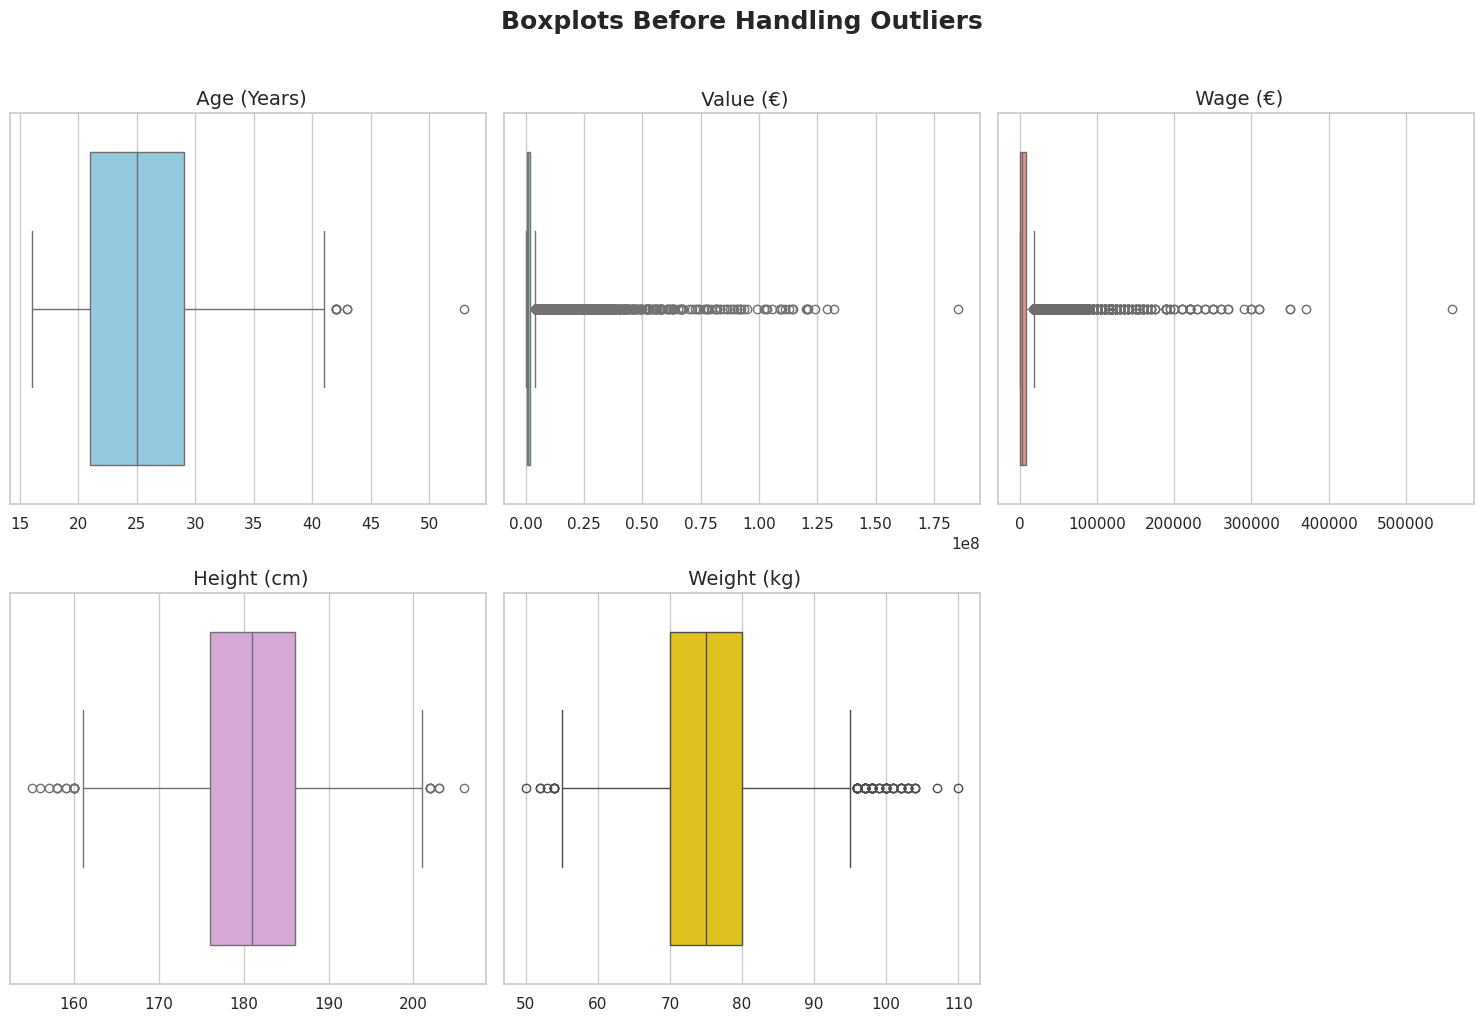

In [30]:
# Visualization to detect the outliers.
cols_to_plot = ['Age', 'Value', 'Wage', 'Height', 'Weight']
titles = ['Age (Years)', 'Value (€)', 'Wage (€)', 'Height (cm)', 'Weight (kg)']
colors = ['skyblue', 'lightgreen', 'salmon', 'plum', 'gold']

# Set up the figure grid (2 rows, 3 columns)
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
fig.suptitle('Boxplots Before Handling Outliers', fontsize=18, fontweight='bold', y=1.02)
axes = axes.flatten()

for i, feature in enumerate(cols_to_plot):
    sns.boxplot(x=df[feature], ax=axes[i], color=colors[i])
    axes[i].set_title(f' {titles[i]}', fontsize=14)
    axes[i].set_xlabel('')

# Remove the empty 6th subplot space for a cleaner look
fig.delaxes(axes[5]) 

plt.tight_layout()
plt.show()

In [31]:
cols_to_handle = ['Age', 'Value', 'Wage', 'Height', 'Weight']

# Detect and Cap outlier using IQR Method
def handle_outliers(df,column):
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3-Q1
    
    # Define acceptable boundary
    lower_bound = Q1-IQR*1.5
    upper_bound = Q3+IQR*1.5
    
    # detect how many oultiers exist before handling
    outliers_count = df[(df[column]<lower_bound) | (df[column]>upper_bound)].shape[0]
    print(f"{column}: {outliers_count} outliers detected.")
    
    # Handle: Cap the values at the upper and lower boundaries
    df[column] = np.where(df[column]>upper_bound,upper_bound,df[column])
    df[column] = np.where(df[column]<lower_bound,lower_bound,df[column])
    
    return df


for col in cols_to_handle:
    df = handle_outliers(df,col)

Age: 8 outliers detected.
Value: 2297 outliers detected.
Wage: 2356 outliers detected.
Height: 22 outliers detected.
Weight: 74 outliers detected.


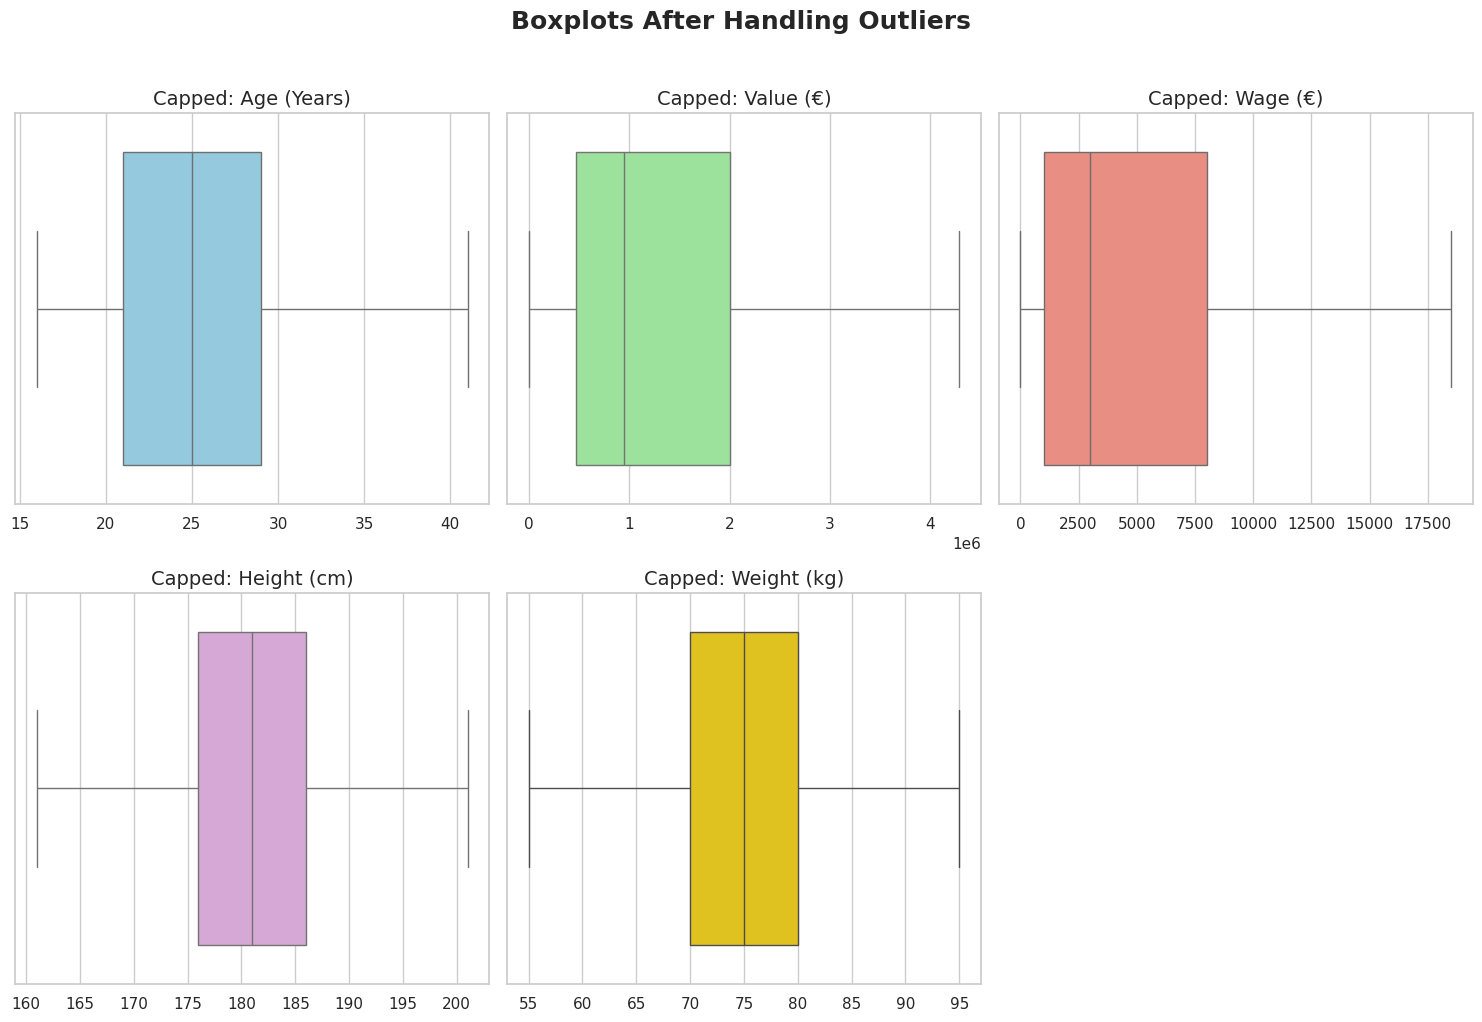

In [32]:
# Visualization after handle the outliers.
cols_to_plot = ['Age', 'Value', 'Wage', 'Height', 'Weight']
titles = ['Age (Years)', 'Value (€)', 'Wage (€)', 'Height (cm)', 'Weight (kg)']
colors = ['skyblue', 'lightgreen', 'salmon', 'plum', 'gold']

# Set up the figure grid (2 rows, 3 columns)
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
fig.suptitle('Boxplots After Handling Outliers', fontsize=18, fontweight='bold', y=1.02)
axes = axes.flatten()

for i, feature in enumerate(cols_to_plot):
    sns.boxplot(x=df[feature], ax=axes[i], color=colors[i])
    axes[i].set_title(f'Capped: {titles[i]}', fontsize=14)
    axes[i].set_xlabel('')

# Remove the empty 6th subplot space for a cleaner look
fig.delaxes(axes[5]) 

plt.tight_layout()
plt.show()

**Outlier Detection:** Outliers were detected in the continuous numerical variable (Age, Value, Wage, Height, Weight) using the Interquartile Range (IQR) method. Due to the severe right-skewness of Value and Wage (representing top-tier superstar players), thousands of statistical outliers were identified.

**Handling Outliers:** 

* **Action:** Handled outliers using IQR Capping (Winsorization) rather than deletion.

* **Justification:** Dropping rows containig financial outliers would have systematically eliminating the highest rated player from the dataset,decreasing model's ability to predict the OVA ratings.Instead, values exceeding the upper bound (Q3+IQR*1.5)and (Q1-IQR*1.5) lower bound were capped at the threshold.This pulls back extreme values into the Normal distribution range.Satisfying the mathematical assumption of the linear machine learning models while retaining the valuable players rows.

### Data Visualization

#### Distribution Plots

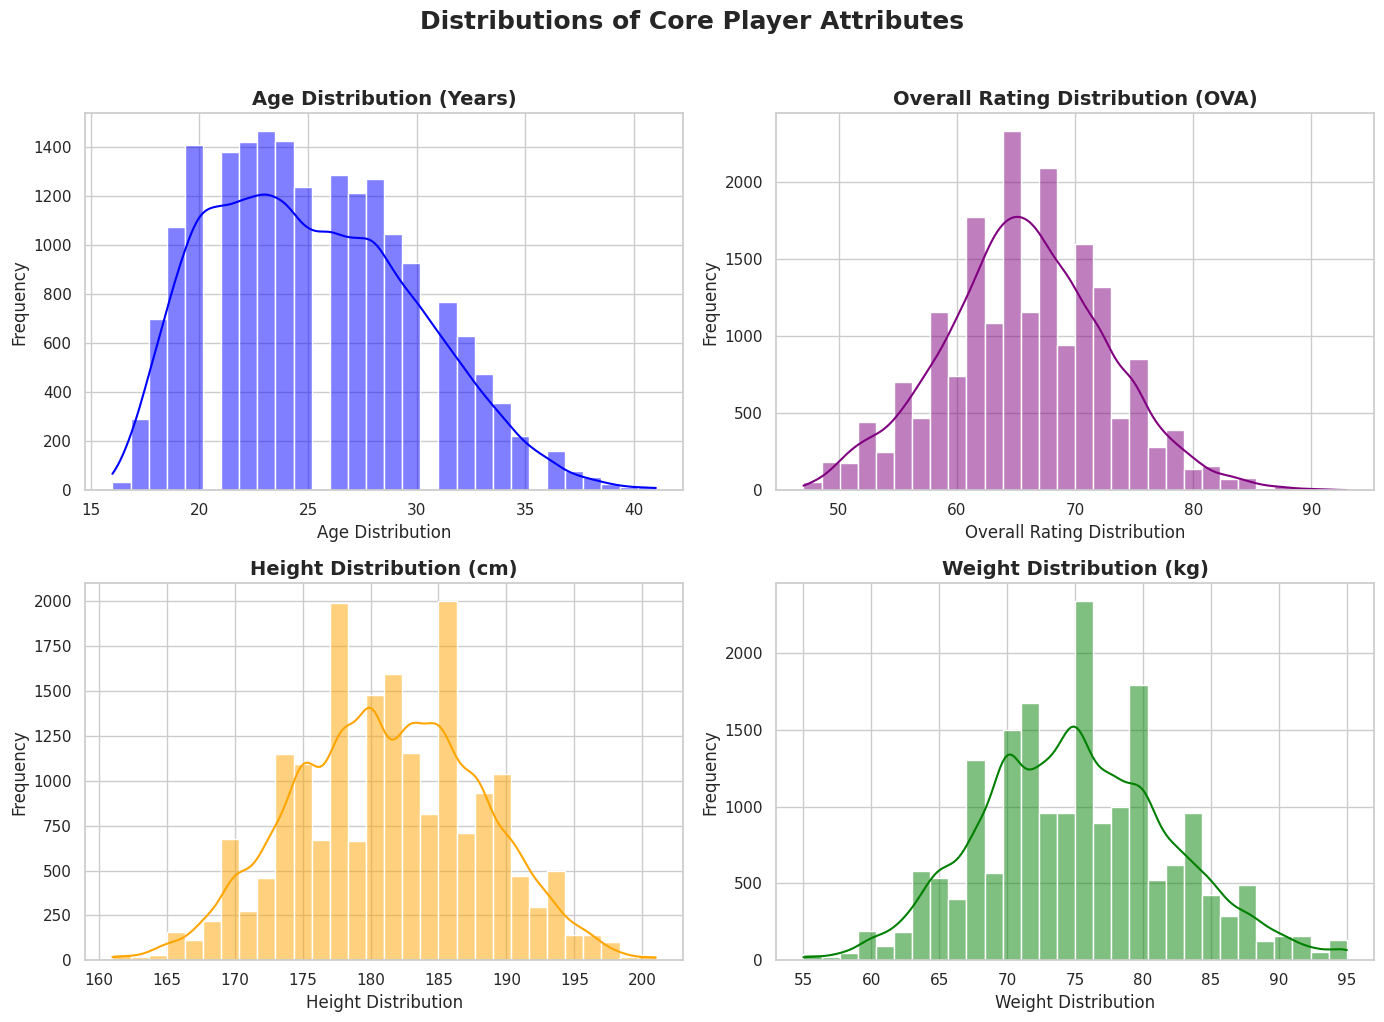

In [33]:
# Distribution Plots for Age,weight,height and target variable OVA
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Define the features we want to plot, their colors, and clean titles
features = ['Age', 'OVA', 'Height', 'Weight']
colors = ['Blue', 'Purple', 'Orange', 'Green'] 
titles = ['Age Distribution (Years)', 'Overall Rating Distribution (OVA)', 
          'Height Distribution (cm)', 'Weight Distribution (kg)']

for i, ax in enumerate(axes.flatten()):
    sns.histplot(df[features[i]], bins=30, kde=True, color=colors[i], ax=ax)
    ax.set_title(titles[i], fontsize=14, fontweight='bold')
    ax.set_xlabel(titles[i].split(' (')[0], fontsize=12)
    ax.set_ylabel('Frequency', fontsize=12)
    
fig.suptitle('Distributions of Core Player Attributes', fontsize=18, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

* **Normally Distributed:** Both OVA, Height, and Weight form beautiful, symmetrical bell curves. This means most players are perfectly average in height, weight, and skill, with very few extremes on either end.

* **Right-Skewed:** Age is slightly right-skewed. The bulk of the players are young (between 20 and 26), and the curve slowly goes off to the right as players retire.

#### Value vs Wage

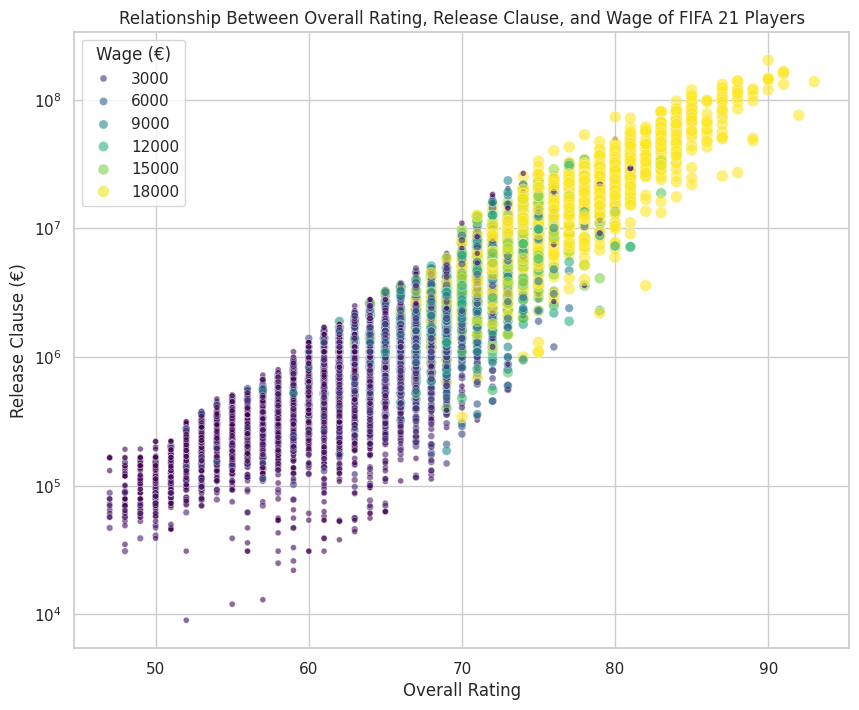

In [34]:
# Relationship Between Overall Rating, Release Clause, and Wage 
# Create a temporary dataframe excluding €0 Release Clauses
plot_df = df[df['Release Clause'] > 0]

plt.figure(figsize=(10, 8))
sns.scatterplot(data=plot_df, x='OVA', y='Release Clause', hue='Wage', size='Wage', alpha=0.6,palette='viridis')
plt.title('Relationship Between Overall Rating, Release Clause, and Wage of FIFA 21 Players')
plt.xlabel('Overall Rating')
plt.ylabel('Release Clause (€)')
plt.legend(title='Wage (€)', loc='upper left')
plt.yscale('log')
plt.show()

* **Overall Rating and Economic Value:** There’s a clear positive correlation between a player’s overall rating and their economic value (both release clause and wage). Players with higher overall ratings tend to have higher release clauses and wages.

* **Release Clause:** The release clause increases significantly for top-rated players, reflecting their high market value. The steep rise for players with ratings above 85 highlights the premium placed on elite talent.

* **Wage:** The color and size of the points indicate the players’ wages. Players with higher wages are generally those with higher overall ratings, but there’s a wider spread in wages than in release clauses. This suggests that wages might be influenced by additional factors like player popularity, club budget, or marketability.

* **High-Rating, High-Value Players:** The top right corner of the plot, where both the overall rating and release clause are high, is sparsely populated. This area represents the elite players in the game, who command both high wages and high release clauses due to their exceptional abilities.

#### Position-specific Analysis

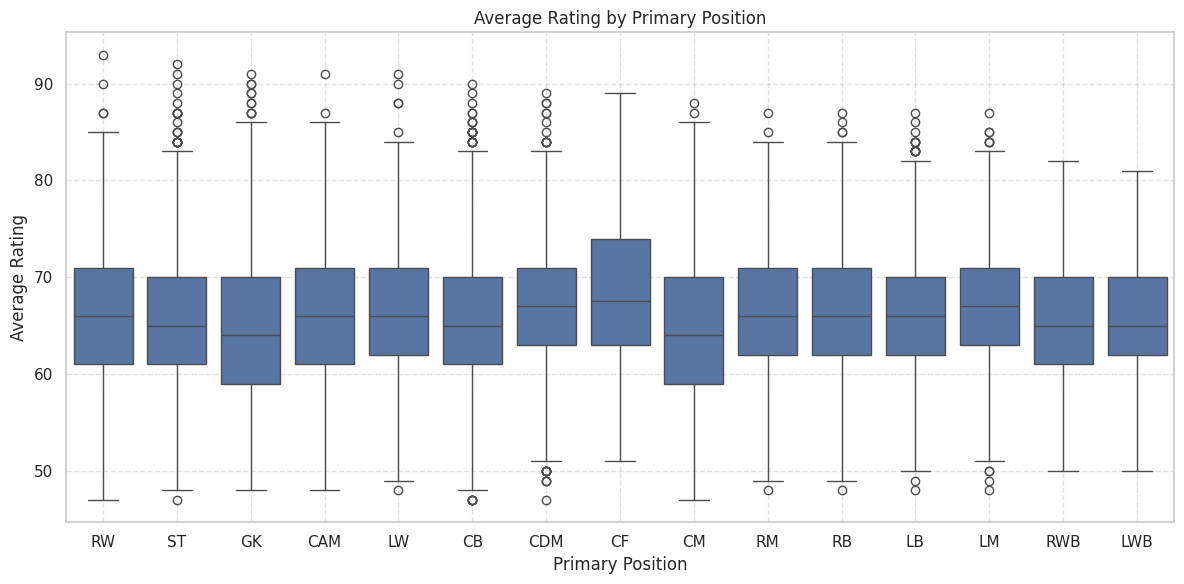

In [35]:
plt.figure(figsize=(12, 6))
sns.boxplot(x='Positions', y='OVA', data=df)
plt.title('Average Rating by Primary Position')
plt.xlabel('Primary Position')
plt.ylabel('Average Rating')
plt.grid(True, linestyle='--', alpha=0.6) 
plt.tight_layout()
plt.show()

**Insights:** 
* Typically, attacking positions (like strikers and wingers) may have higher average ratings, reflecting the premium on goal-scoring abilities in football.

* Defensive positions might have lower average ratings but could excel in specific attributes like physicality or defense.

#### Age vs Performance

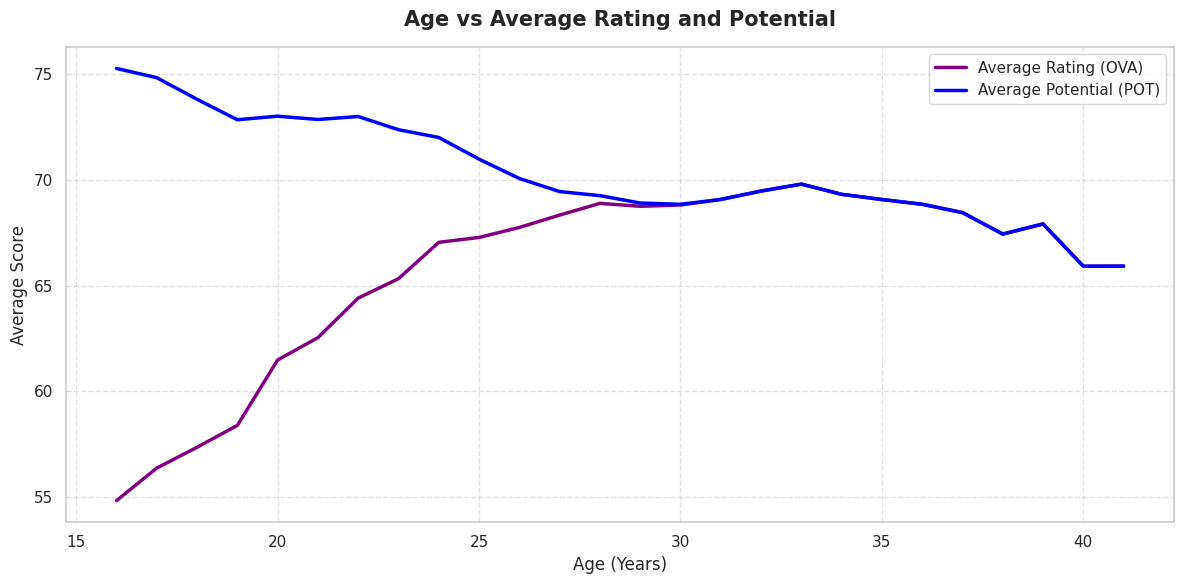

In [36]:
# Age vs Performance
age_performance = df.groupby('Age').agg(
    Average_Rating=('OVA', 'mean'),
    Average_Potential=('POT', 'mean')
)

age_performance[['Average_Rating', 'Average_Potential']].plot(
    kind='line',
    figsize=(12,6),
    linewidth=2.5,
    color=['Purple', 'Blue'])

plt.title('Age vs Average Rating and Potential', fontsize=15, fontweight='bold', pad=15)
plt.xlabel('Age (Years)', fontsize=12)
plt.ylabel('Average Score', fontsize=12)
plt.legend(['Average Rating (OVA)', 'Average Potential (POT)'])
plt.grid(True, linestyle='--', alpha=0.6) 
plt.tight_layout()
plt.show()

**Insights:**
* Players generally peak between the ages of 27 and 32, with a gradual decline afterward.
* Young players (under 21) often have high potential ratings, indicating their future growth in the game.

#### Correlation Matrix

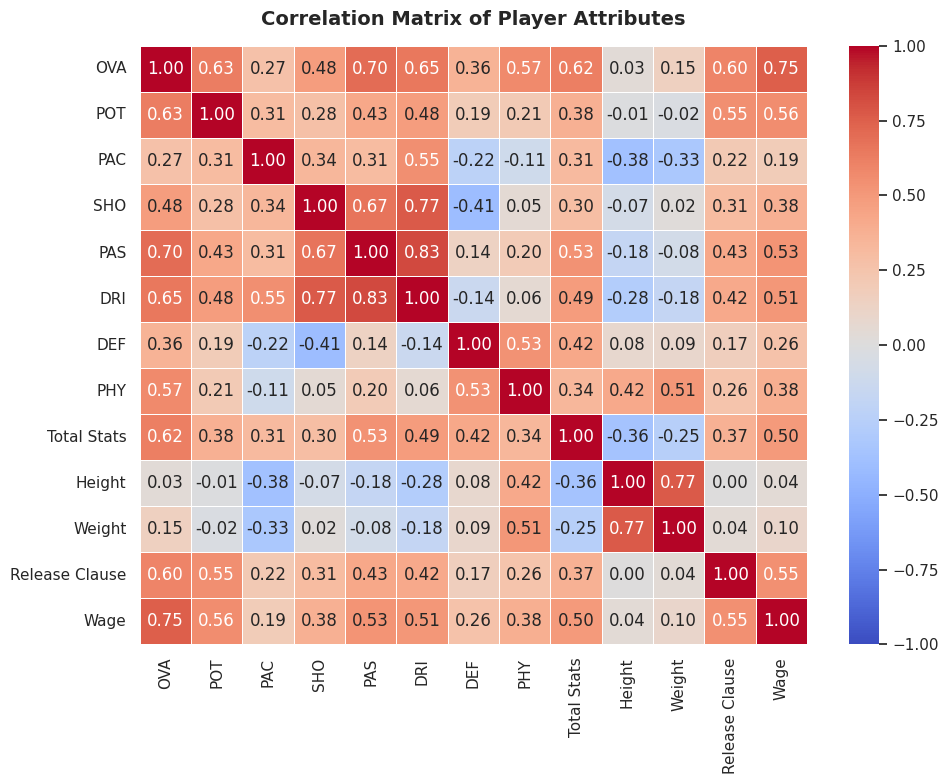

In [37]:
correlation_matrix = df[['OVA', 'POT', 'PAC', 'SHO', 'PAS', 'DRI', 'DEF', 'PHY','Total Stats', 'Height', 'Weight', 'Release Clause', 'Wage']].corr()

plt.figure(figsize=(10,8))
sns.heatmap(correlation_matrix,annot=True,cmap='coolwarm',fmt=".2f", linewidths=0.5, vmin=-1, vmax=1)
plt.title('Correlation Matrix of Player Attributes',fontsize=14, fontweight='bold',pad=15)
plt.tight_layout()
plt.show()

**Insights:**
* There is a higher correlation between player's overall abilities and their individual attributes like PAS,DRI and SHO.
* OVA,Release Clause and Wage are highly correlate with each other.This proves mathematically that as player's rating goes up,both release clause and wages scale up together.

#### Rating Distribution by Broader postitions

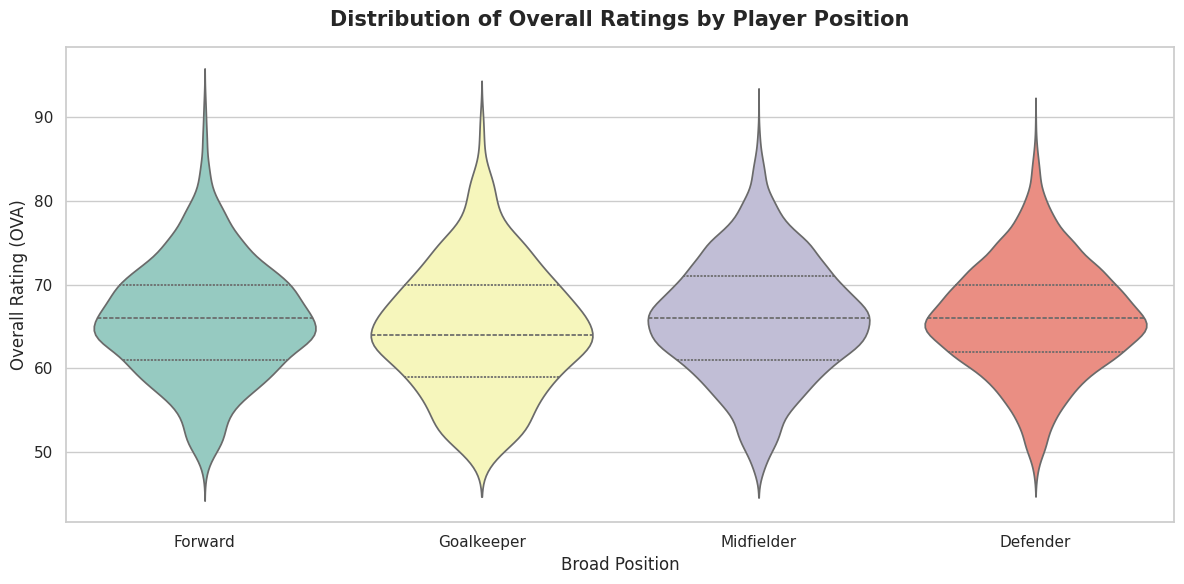

In [38]:
position_mapping = {
    'ST': 'Forward', 'LW': 'Forward', 'RW': 'Forward', 'CF': 'Forward',
    'CAM': 'Midfielder', 'CM': 'Midfielder', 'CDM': 'Midfielder', 'LM': 'Midfielder', 'RM': 'Midfielder',
    'CB': 'Defender', 'LB': 'Defender', 'RB': 'Defender', 'LWB': 'Defender', 'RWB': 'Defender',
    'GK': 'Goalkeeper'
}

# Create a temporary column for the plot
df['Broad Position'] = df['Best Position'].map(position_mapping)

plt.figure(figsize=(12,6))
sns.violinplot(x='Broad Position',y='OVA',data=df,palette='Set3',inner='quartile')
plt.title('Distribution of Overall Ratings by Player Position', fontsize=15, fontweight='bold', pad=15)
plt.xlabel('Broad Position', fontsize=12)
plt.ylabel('Overall Rating (OVA)', fontsize=12)
plt.tight_layout()
plt.show()

**Insights:**
* GoalKeeper has a very fat,wide distribution at the bottom(meaning there are thousands of low rated GoalKeeper) and a very thin distribution at the top(very few world class GKs).

* Midfielders have a much fatter middle section, proving that the vast majority of midfielders in the game are solidly "average" (around 68-70 rating).

In [39]:
df = df.drop(columns=['Broad Position'])

#### High Density Scatter plot (Total Stats vs OVA)

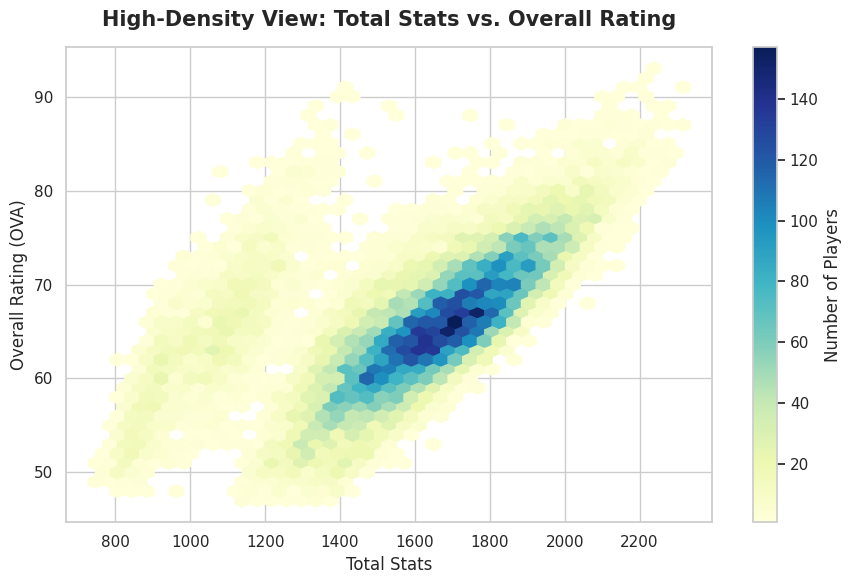

In [40]:
plt.figure(figsize=(9, 6))
# mincnt=1 ensures we don't plot empty hexagons
plt.hexbin(df['Total Stats'], df['OVA'], gridsize=40, cmap='YlGnBu', mincnt=1)
cb = plt.colorbar(label='Number of Players')
plt.title('High-Density View: Total Stats vs. Overall Rating', fontsize=15, fontweight='bold', pad=15)
plt.xlabel('Total Stats', fontsize=12)
plt.ylabel('Overall Rating (OVA)', fontsize=12)
plt.tight_layout()
plt.show()

**Insights:**
* The dark blue cluster right in the middle (Total Stats betwnn ~1600 to 1800, OVA ~62 to 68).
* This visually proves exactly where the "average" FIFA player lives. It also shows a very distinct, tight linear correlation.There are outliers on the bottom as well.Those are players with massive Total Stats but low OVA ratings (often fast, strong young players with terrible technical skills).

#### Top 10 Club by Average Rating

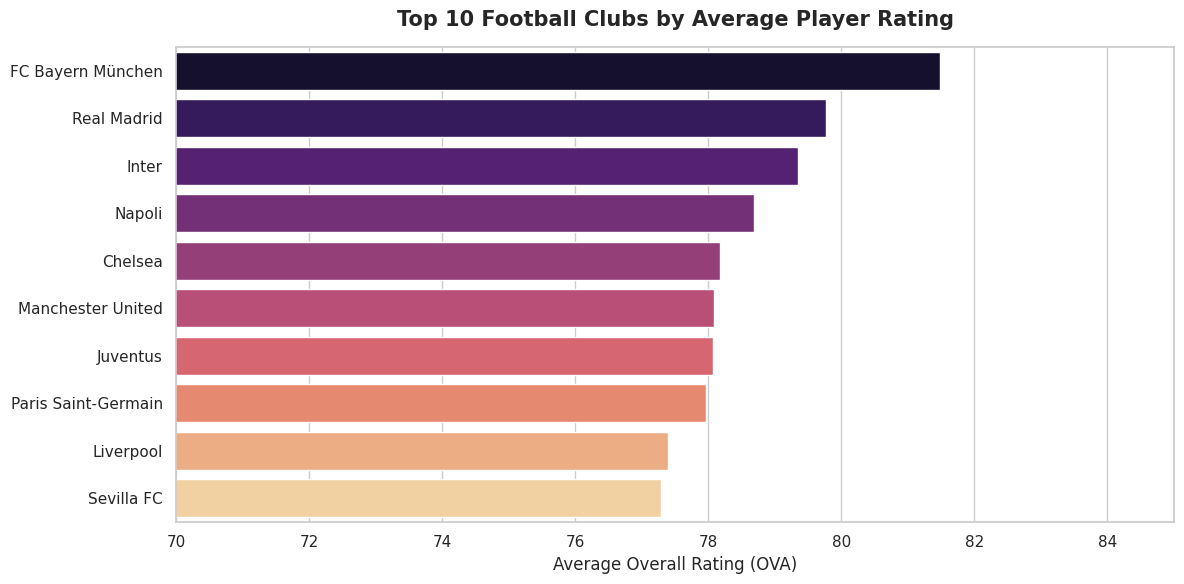

In [41]:
# Filter for clubs that have at least 15 players to avoid skewed data
df['Club'] = df['Club'].str.strip()
valid_clubs = df['Club'].value_counts()
valid_clubs = valid_clubs[valid_clubs>=15].index

# Group by Club,calculate the mean OVA and sort the top 10
top_10_clubs = df[df['Club'].isin(valid_clubs)].groupby('Club')['OVA'].mean().sort_values(ascending=False).head(10)

plt.figure(figsize=(12,6))
sns.barplot(x=top_10_clubs.values,y=top_10_clubs.index,palette='magma')
plt.title('Top 10 Football Clubs by Average Player Rating', fontsize=15, fontweight='bold', pad=15)
plt.xlabel('Average Overall Rating (OVA)', fontsize=12)
plt.ylabel('')
plt.xlim(70, 85)
plt.tight_layout()
plt.show()

**Insight:** FC Bayern München, Real Madrid, and Inter Milan sit at the top with most no.of players have Average OVA rating more than 78,followed by other world class football clubs like Napoli,Chelsea and Manchester United.

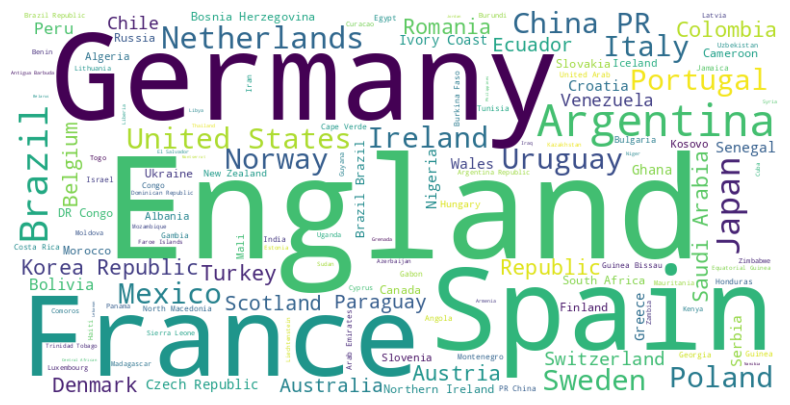

In [42]:
from wordcloud import WordCloud
#WordCloud Of Nationality
countries = df['Nationality']

wordcloud = WordCloud(
                   background_color='white',
                        width = 800,
                        height = 400
    ).generate(" ".join(countries))

plt.figure(figsize=(10, 5))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off') # Hide axes
plt.show()

**Insights:** England,Germany,France and Spain have highest number of players in the fifa dataset that shows European countries produces most no. of players in the football.

In [43]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 18979 entries, 0 to 18978
Data columns (total 75 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   ID                18979 non-null  int64  
 1   Name              18979 non-null  str    
 2   Nationality       18979 non-null  str    
 3   Age               18979 non-null  float64
 4   OVA               18979 non-null  int64  
 5   POT               18979 non-null  int64  
 6   Club              18979 non-null  str    
 7   Positions         18979 non-null  object 
 8   Height            18979 non-null  float64
 9   Weight            18979 non-null  float64
 10  Preferred Foot    18979 non-null  str    
 11  BOV               18979 non-null  int64  
 12  Best Position     18979 non-null  str    
 13  Value             18979 non-null  float64
 14  Wage              18979 non-null  float64
 15  Release Clause    18979 non-null  float64
 16  Attacking         18979 non-null  int64  
 17  Cros

## Task D: Data Transformation

### categorical encoding

In [44]:
# Label Encoding for Binary Categorical Variables
df['Preferred Foot'] = df['Preferred Foot'].map({'Left':0,'Right':1})

# One-Hot Encoding for multi-class variables
columns_to_encode = ['Contract_status','Best Position']

# drop_first=True helps prevent multicollinearity (the dummy variable trap)
df = pd.get_dummies(df,columns=columns_to_encode,drop_first=True,dtype=int)

print("Categorical Encoding Complete! New dataframe shape:", df.shape)

Categorical Encoding Complete! New dataframe shape: (18979, 88)


**Justification:**
* **Binary Label Encoding:** Applied to Preferred Foot, converting 'Left' and 'Right' into binary 0s and 1s to satisfy algorithm input requirements without increasing dimensionality.

* **One-Hot Encoding:** Applied to nominal variables like Contract_Status and Best Position. drop_first=True was utilized to avoid the 'dummy variable trap', explicitly preventing perfect multicollinearity among the newly created features.

In [45]:
# Ordinal Encode for A/W & D/W (Low=0, Medium=1, High=2)
mapping = {'Low': 0, 'Medium': 1, 'High': 2}
df['A/W'] = df['A/W'].map(mapping)
df['D/W'] = df['D/W'].map(mapping)

**Justification:** Applied to A/W & D/W, map 'Low','Medium' and 'High' into 0,1 and 2 to satisfy algorithm input requirements without increasing dimensionality.

### Feature Scaling

#### BMI Index

In [46]:
# BMI Formula: Weight (kg) / [Height (m)]^2
# height is currently in cm, so we divide by 100 to get meters
height_in_meters = df['Height'] / 100
df['BMI'] = df['Weight'] / (height_in_meters ** 2)

# Scale the new feature
# Intialize the scaler
scaler = MinMaxScaler()
df[['BMI']] = scaler.fit_transform(df[['BMI']])

**Justification:** In Correlation Matrix,I found that Height and Weight alone have almost zero correlation with the target variable OVA.However, the ratio of height to weight (BMI) might indicate if a player is highly athletic or out of shape, which could be a hidden predictor of their physical stats (PHY).

**Note**: I created BMI index before Scaling to avoid Zero Division Error / infinite value error.

In [47]:
cols_to_scale = ['Age', 'Height', 'Weight', 'Value', 'Wage', 'Release Clause', 'Hits']

df[cols_to_scale] = scaler.fit_transform(df[cols_to_scale])
print("\n--- Summary of Scaled Features (Min=0, Max=1) ---")
print(df[cols_to_scale].describe().round(2).loc[['min', 'max', 'mean']])


--- Summary of Scaled Features (Min=0, Max=1) ---
       Age  Height  Weight  Value  Wage  Release Clause  Hits
min   0.00    0.00     0.0   0.00  0.00            0.00   0.0
max   1.00    1.00     1.0   1.00  1.00            1.00   1.0
mean  0.37    0.51     0.5   0.34  0.31            0.02   0.0


**Justification:** Continuous Numerical Variables(e.g., Age, Wage, Value) existed on different scales.Left unscaled, distance-based or gradient descent algorithms would assign disproportionate mathematical weight to high-magnitude features like Value. Min-Max scaling was applied to compress all continuous features into a strict [0, 1] bounded range, ensuring equal algorithmic weighting while preserving the original distributional shape of the data.

In [48]:
# Create a list of the base ability stats
ability_cols = ['POT','PAC', 'SHO', 'PAS', 'DRI', 'DEF', 'PHY']

# Scale them to a [0, 1] range simply by dividing by 100
df[ability_cols] = df[ability_cols] / 100

print("Player abilities successfully scaled to [0, 1] range!")
print(df[ability_cols].head(3))

Player abilities successfully scaled to [0, 1] range!
    POT   PAC   SHO   PAS   DRI   DEF   PHY
0  0.93  0.85  0.92  0.91  0.95  0.38  0.65
1  0.92  0.89  0.93  0.81  0.89  0.35  0.77
2  0.93  0.87  0.92  0.78  0.90  0.52  0.90


**Justification:** Player ability metrics (e.g., PAC, SHO) and Future Potential (POT) exist on a naturally bounded integer scale of 1 to 99. To ensure absolute uniformity across the entire feature matrix for distance-based algorithms, these bounded features were normalized to a [0, 1] scale by dividing by 100.

### Feature Engineering

I already did some feature engineering tasks in Data Cleaning step where i extracted Contract_status,Contract_Start and Contract_End from the messy 'Contract' Feature.and also created BMI feature before scaling to avoid zero division error for the minimum height value, corrupting the feature matrix

#### Age_group (Binning/Discretization)

In [49]:
# Create Categorical bins for the Age
bins = [15,21,26,32,55]
labels = ['WonderKid','Young', 'Peak', 'Veteran']
df['Age_group'] = pd.cut(df['Age'],bins=bins,labels=labels)

# One_Hot Encoding for this new feature
df = pd.get_dummies(df, columns=['Age_group'], drop_first=True,dtype=int)

**Justification:** As we saw in our EDA line chart, age has a curved relationship with rating (players peak around 30). Linear machine learning models struggle with curves. By converting continuous age into categorical "bins", we help the model understand the lifecycle of a player and subsequently performed One-Hot Encoding as well.

#### Value_to_Wage_Ratio

In [50]:
# use np.where to avoid dividing by 0 if wage is zero
df['Value_to_Wage_Ratio'] = np.where(df['Wage']>0,df['Value']/df['Wage'],0)

# Scale this new feature just like the others
df[['Value_to_Wage_Ratio']] = scaler.fit_transform(df[['Value_to_Wage_Ratio']])

**Justification:** Sometimes, a player is on massive wages but their actual transfer value is low (meaning they are an overpaid, declining veteran). Conversely, a young player might have a huge value but a low wage. Creating a ratio between these two tells the model how "efficient" a player's contract is.

### Droppin some redundant features before splitting the data

In [51]:
# Drop Identifiers, Redundant strings, and Data Leakage columns
cols_to_drop = ['ID', 'Name', 'Nationality', 'Club', 'Positions', 'BOV', 'Total Stats', 'Base Stats']
df = df.drop(columns=cols_to_drop, errors='ignore')

# Drop the granular stats (keeping only the 6 Base Stats: PAC, SHO, PAS, DRI, DEF, PHY)
granular_stats = [
    'Attacking', 'Crossing', 'Finishing', 'Heading Accuracy', 'Short Passing', 'Volleys', 
    'Skill', 'Dribbling', 'Curve', 'FK Accuracy', 'Long Passing', 'Ball Control', 
    'Movement', 'Acceleration', 'Sprint Speed', 'Agility', 'Reactions', 'Balance', 
    'Power', 'Shot Power', 'Jumping', 'Stamina', 'Strength', 'Long Shots', 
    'Mentality', 'Aggression', 'Interceptions', 'Positioning', 'Vision', 'Penalties', 
    'Composure', 'Defending', 'Marking', 'Standing Tackle', 'Sliding Tackle', 
    'Goalkeeping', 'GK Diving', 'GK Handling', 'GK Kicking', 'GK Positioning', 'GK Reflexes'
]
df = df.drop(columns=granular_stats, errors='ignore')

**Justification:** 
* **Dropped Identifiers and High Cardinality Features:** Drop **ID** and **Name**,Players barcode no. and name almost has zero predicted power for their Overall Rating.Dropping **'Nationality'** and **'Club'**,while a club like Real Madrid has highly-rated players, encoding these columns would create hundreds of new dummy columns (High Cardinality). This creates a massive, sparse matrix that will slow your model to a crawl and cause overfitting.we already engineered and encoded **'Best Position'**, making the raw Positions string list completely redundant.

* **Data Leakage and Multicollinearity:** **BOV(Best Overall)** is highly correlated with target variable.In many cases it almost same number.if we leave it, model will only look at this and predict OVA and ignore all other stats.This is a classic Data Leakage Issue.**'Total Stats'** and **'Base Stats'** these are literally just the mathematical sum of the other skills in the dataset, leaving them in alongside the individual skills causes severe Multicollinearity.

* **Dropping Granular Stats:** This dataset currently contains the 6 high-level Base Stats (PAC, SHO, PAS, DRI, DEF, PHY) AND the 30+ granular stats like (Sprint Speed, Finishing, Short Passing, etc.).So i am not going to keep both because keeping both is highly redundant. I will drop 30+ granular stats and keeping only the Base Stats.It makes your model much faster, cleaner, and less prone to overfitting.

In [52]:
df.head()

,Age,OVA,POT,Height,Weight,Preferred Foot,Value,Wage,Release Clause,W/F,SM,A/W,D/W,IR,PAC,SHO,PAS,DRI,DEF,PHY,Hits,Joined_Year,Contract_Start,Contract_End,Contract_status_Free,Best Position_CB,Best Position_CDM,Best Position_CF,Best Position_CM,Best Position_GK,Best Position_LB,Best Position_LM,Best Position_LW,Best Position_LWB,Best Position_RB,Best Position_RM,Best Position_RW,Best Position_RWB,Best Position_ST,BMI,Age_group_Young,Age_group_Peak,Age_group_Veteran,Value_to_Wage_Ratio
0,0.68,93,0.93,0.225,0.425,0,1.0,1.0,0.681438,4,4,1,0,5,0.85,0.92,0.91,0.95,0.38,0.65,0.091678,2004,2004,2021,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0.598398,0,0,0,0.027027
1,0.76,92,0.92,0.650,0.700,1,1.0,1.0,0.373708,4,5,2,0,5,0.89,0.93,0.81,0.89,0.35,0.77,0.066794,2018,2018,2022,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0.505074,0,0,0,0.027027
2,0.44,91,0.93,0.675,0.800,1,1.0,1.0,0.784835,3,1,1,1,3,0.87,0.92,0.78,0.90,0.52,0.90,0.017740,2014,2014,2023,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0.574771,0,0,0,0.027027
3,0.52,91,0.91,0.500,0.375,1,1.0,1.0,0.792713,5,4,2,2,4,0.76,0.86,0.93,0.88,0.64,0.78,0.024527,2015,2015,2023,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0.317470,0,0,0,0.027027
4,0.48,91,0.91,0.350,0.325,1,1.0,1.0,0.819793,5,5,2,1,5,0.91,0.85,0.86,0.94,0.36,0.59,0.070723,2017,2017,2022,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0.383785,0,0,0,0.027027


In [53]:
df.shape

(18979, 44)

In [54]:
true_ml_drops = ['POT', 'Value', 'Wage', 'Release Clause', 'Value_to_Wage_Ratio']
df = df.drop(columns=true_ml_drops, errors='ignore')

**Justification:**
* **POT(Potential):** For players who have reached their peak development age(typically >28),thier POT score is strickly locked to their OVA score.Retainig POT could acts as proxy for the target variable and could inflate the model accuracy.

* **Exclusion of Financial Metrics (Value, Wage, Release Clause,Value_to_Wage_Ratio):** The Goal of ML model is to predict the OVA(Overall Ability/Rating)based on skills,using finanical metrics causes 'Leakage'.A Player's wage and Release Clause are heavily derived from their existing Overall Rating. Including them makes the model trivial, as it is simply predicting a value using a metric directly influenced by that value.

## Task E: Train/Test Dataset Preparation

In [55]:
# 1. Define the Target (y) and the Features (X)
# drop 'OVA' because it is what we are trying to predict
y = df['OVA']
X = df.drop(columns=['OVA'])

# 2. Perform the Train/Test Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 3. Print the final matrix dimensions to verify success
print("--- Task E: Train/Test Split Complete ---")
print(f"Training Matrix Shape (X_train): {X_train.shape}")
print(f"Testing Matrix Shape (X_test): {X_test.shape}")
print(f"Target Training Shape (y_train): {y_train.shape}")
print(f"Target Testing Shape (y_test): {y_test.shape}")

--- Task E: Train/Test Split Complete ---
Training Matrix Shape (X_train): (15183, 38)
Testing Matrix Shape (X_test): (3796, 38)
Target Training Shape (y_train): (15183,)
Target Testing Shape (y_test): (3796,)


**Justification:**

**The Necessity of the Train-Test Split:**
* Splitting the dataset into training set(80%) and testing set(20%) is fundamental requirement in predicting modeling to evaluate model's true capability to generalize to unseen data.Machine learning algorithms,are highly susceptible to overfitting--the mathematical memorization of noise and specific data points within the training matrix.
* if a model is evaluated on the exact same data it was trained on, the resulting accuracy metric will be artificially inflated,representing model's memory rather than its predictive intelligence.By separating or splitting the 20% as test set, we simulate the real world deployment enviroment.Evaluating model on the unseen data is the only mathematical valid way to calculate true error metrics (such as MAE and RMSE) and ensure the algorithm has successfully learned the underlying general patterns of the data.

### Feature Selection using RFE (Recursive Feature Elimination Method)

In [56]:
print(f"Original number of features: {X_train.shape[1]}")

# 1. Initialize a base model for the wrapper to use
# We use a Regressor because OVA is a continuous number
base_model = RandomForestRegressor(random_state=42)

# 2. Initialize the RFE Wrapper Method
# find the Top 15 most important features
rfe = RFE(estimator=base_model, n_features_to_select=15)

# 3. FIT THE RFE STRICTLY ON THE TRAINING DATA
rfe.fit(X_train, y_train)

# 4. Transform BOTH the training and testing sets to keep only those 15 features
X_train_selected = rfe.transform(X_train)
X_test_selected = rfe.transform(X_test)

print(f"Reduced number of features: {X_train_selected.shape[1]}")

# 5. See which features the Wrapper Method actually kept!
selected_feature_names = X_train.columns[rfe.support_]
print("\nThe Top 15 Selected Features are:")
for feature in selected_feature_names:
    print(f"- {feature}")

Original number of features: 38
Reduced number of features: 15

The Top 15 Selected Features are:
- Age
- Height
- Weight
- IR
- PAC
- SHO
- PAS
- DRI
- DEF
- PHY
- Hits
- Joined_Year
- Contract_End
- Best Position_CB
- BMI


### **Algorithmic Feature Selection (Wrapper Method)**

Following the Train/Test split, a Wrapper Method—specifically **Recursive Feature Elimination (RFE)** utilizing a `RandomForestRegressor` estimator—was applied strictly to the training data. This algorithmic process systematically evaluated feature importance and eliminated redundant features, successfully reducing the feature matrix down to the top 15 most mathematically predictive features:

* **Physical & Biological:** `Age`, `Height`, `Weight`, `BMI`
* **Technical & Base Stats:** `PAC`, `SHO`, `PAS`, `DRI`, `DEF`, `PHY`, `IR` (International Reputation)
* **Career & Market Context:** `Hits`, `Joined_Year`, `Contract_End`, `Best Position_CB`

> **Methodological Note regarding Temporal Data Scaling:**  While continuous variables (like physical and financial metrics) were Min-Max scaled to a `[0, 1]` range, temporal features (`Joined_Year` and `Contract_End`) were intentionally retained in their raw integer formats. Scaling these features is mandatory for distance-based algorithms (such as KNN or SVM) to prevent magnitude dominance. However, tree-based models like Random Forests are invariant to monotonic transformations. Because decision trees segment data using pure numerical thresholds (e.g., `Joined_Year <= 2019`) rather than calculating Euclidean distance, scaling these temporal values is mathematically unnecessary for our chosen algorithm.

In [57]:
# Define the exact Top 15 features selected by your Wrapper Method
final_features = [
    'Age', 'Height', 'Weight','IR','PAC','SHO','PAS','DRI','DEF','PHY','Hits','Joined_Year','Contract_End','Best Position_CB','BMI'
]

# Add the target variable ('OVA') so it is included in the final CSV
final_columns = final_features + ['OVA']

# Filter the main dataset to ONLY keep these 16 columns
df = df[final_columns]

print(f"Number of features (15 features + 1 target): {df.shape[1]}")

Number of features (15 features + 1 target): 16


## Task F: Final Clean Dataset

In [58]:
# Calculate and print the final dimensions
num_rows = df.shape[0]
num_features = df.shape[1]

print("--- Final Dataset Summary ---")
print(f"Number of rows remaining: {num_rows}")
print(f"Number of features: {num_features} (Including target variable 'OVA')\n")

# 2. Display a sample preview of the cleaned data
print("Sample preview of cleaned data:")
# If using Jupyter Notebook, display() renders a beautiful HTML table
display(df.head()) 

# 3. Export the final dataset for submission
export_filename = 'fifa21_cleaned_ml_ready.csv'
df.to_csv(export_filename, index=False)

print(f"\nSuccess! Final dataset exported as '{export_filename}'.")
print("The dataset is officially ready for Machine Learning training.")

--- Final Dataset Summary ---
Number of rows remaining: 18979
Number of features: 16 (Including target variable 'OVA')

Sample preview of cleaned data:


,Age,Height,Weight,IR,PAC,SHO,PAS,DRI,DEF,PHY,Hits,Joined_Year,Contract_End,Best Position_CB,BMI,OVA
0,0.68,0.225,0.425,5,0.85,0.92,0.91,0.95,0.38,0.65,0.091678,2004,2021,0,0.598398,93
1,0.76,0.650,0.700,5,0.89,0.93,0.81,0.89,0.35,0.77,0.066794,2018,2022,0,0.505074,92
2,0.44,0.675,0.800,3,0.87,0.92,0.78,0.90,0.52,0.90,0.017740,2014,2023,0,0.574771,91
3,0.52,0.500,0.375,4,0.76,0.86,0.93,0.88,0.64,0.78,0.024527,2015,2023,0,0.317470,91
4,0.48,0.350,0.325,5,0.91,0.85,0.86,0.94,0.36,0.59,0.070723,2017,2022,0,0.383785,91



Success! Final dataset exported as 'fifa21_cleaned_ml_ready.csv'.
The dataset is officially ready for Machine Learning training.


## Model Evaluation

In [59]:
# 1. Initialize and Train the Model using the TRAINING data
# We are using the X_train_selected from our Wrapper Method!
model = RandomForestRegressor(random_state=42)
model.fit(X_train_selected, y_train)

# 2. Make Predictions using the unseen TESTING data
y_pred = model.predict(X_test_selected)

# 3. Calculate the Evaluation Metrics
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

# 4. Print the Results
print("\n--- Model Evaluation Results ---")
print(f"Mean Absolute Error (MAE): {mae:.3f} rating points")
print(f"Root Mean Squared Error (RMSE): {rmse:.3f} rating points")
print(f"R-Squared (R2 Score): {r2:.3f} ({r2*100:.1f}%)")


--- Model Evaluation Results ---
Mean Absolute Error (MAE): 0.999 rating points
Root Mean Squared Error (RMSE): 1.312 rating points
R-Squared (R2 Score): 0.963 (96.3%)


**Interpretation:** 
* **R2 Score (0.963 / 96.3%):** It means 96.3% of the variance in the ratings is explained by the model. The model fits the training/test data very well,indicating a high correlation between predicted and actual rating.
* **Mean Absolute Error (MAE: 0.999):** On average, the predictions are off by roughly 1 rating point.
* **Root Mean Squared Error (RMSE: 1.312):** Since the RMSE (1.312) is higher than the MAE (0.999), it indicates that there are some larger errors/outliers in the predictions. The squaring process in RMSE penalizes these larger deviations more heavily than the linear MAE.